<a href="https://colab.research.google.com/github/MUHAMMADAZAN1/Ai-lab-Assignment/blob/main/snake.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install pygame and imageio for saving the gameplay animation
!pip install pygame imageio

In [2]:
import os
import random
import pygame
import imageio

# 1. Force Pygame to use a dummy video driver for Google Colab environment
os.environ["SDL_VIDEODRIVER"] = "dummy"

# Initialize Pygame
pygame.init()

# Window dimensions
WINDOW_X = 600
WINDOW_Y = 400

# Color definitions (RGB)
BLACK = (0, 0, 0)
WHITE = (255, 255, 255)
GREEN = (0, 255, 0)
RED = (255, 0, 0)
YELLOW = (255, 255, 0)
GRAY = (100, 100, 100)

# Game settings
SNAKE_BLOCK = 10
BASE_SPEED = 15

# Initialize surface
screen = pygame.display.set_mode((WINDOW_X, WINDOW_Y))
clock = pygame.time.Clock()

def spawn_food(obstacles, snake_body):
    """Spawns food safely away from walls, obstacles, and the snake body."""
    while True:
        pos = [
            random.randrange(1, (WINDOW_X // SNAKE_BLOCK)) * SNAKE_BLOCK,
            random.randrange(1, (WINDOW_Y // SNAKE_BLOCK)) * SNAKE_BLOCK
        ]
        if pos not in obstacles and pos not in snake_body:
            return pos

def run_snake_simulation():
    # Snake initial state
    snake_pos = [100, 50]
    snake_body = [[100, 50], [90, 50], [80, 50]]
    direction = 'RIGHT'
    change_to = direction

    # Score track
    score = 0

    # Define Obstacles (Lab Task 2.3)
    obstacles = []
    # Adding a simple interior block wall obstacle
    for i in range(150, 250, SNAKE_BLOCK):
        obstacles.append([i, 150])
        obstacles.append([i, 250])

    # Initial Food Setup
    normal_food_pos = spawn_food(obstacles, snake_body)
    bonus_food_pos = None
    bonus_active = False

    # Frame capture storage
    frames = []
    game_over = False

    # Run loop for a max of 1000 frames or until crash to demonstrate in Colab
    for _ in range(1000):
        if game_over:
            break

        # Simulated automated movement strategy for Colab demonstration
        # (Alternates or targets food safely instead of manual human keyboard input)
        if snake_pos[0] < normal_food_pos[0] and direction != 'LEFT': change_to = 'RIGHT'
        elif snake_pos[0] > normal_food_pos[0] and direction != 'RIGHT': change_to = 'LEFT'
        elif snake_pos[1] < normal_food_pos[1] and direction != 'UP': change_to = 'DOWN'
        elif snake_pos[1] > normal_food_pos[1] and direction != 'DOWN': change_to = 'UP'

        direction = change_to

        # Update position based on direction
        if direction == 'UP': snake_pos[1] -= SNAKE_BLOCK
        elif direction == 'DOWN': snake_pos[1] += SNAKE_BLOCK
        elif direction == 'LEFT': snake_pos[0] -= SNAKE_BLOCK
        elif direction == 'RIGHT': snake_pos[0] += SNAKE_BLOCK

        # Snake body mechanics
        snake_body.insert(0, list(snake_pos))

        # Check normal food consumption
        if snake_pos == normal_food_pos:
            score += 10
            normal_food_pos = spawn_food(obstacles, snake_body)
        # Check bonus food consumption (Lab Task 2.2)
        elif bonus_active and snake_pos == bonus_food_pos:
            score += 20  # Double marks
            bonus_active = False
            bonus_food_pos = None
        else:
            snake_body.pop()

        # Lab Task 2.2: Handle spawning bonus yellow fruit if score > 150
        if score > 150 and not bonus_active:
            bonus_food_pos = spawn_food(obstacles, snake_body)
            bonus_active = True

        # Game Over Conditions (Lab Task 1.3)
        # Wall collision
        if snake_pos[0] < 0 or snake_pos[0] >= WINDOW_X or snake_pos[1] < 0 or snake_pos[1] >= WINDOW_Y:
            game_over = True
        # Self collision
        if snake_pos in snake_body[1:]:
            game_over = True
        # Obstacle collision (Lab Task 2.3)
        if snake_pos in obstacles:
            game_over = True

        # Adjust game speed dynamically (Lab Task 2.1)
        current_speed = BASE_SPEED * 2 if score > 100 else BASE_SPEED

        # --- DRAWING OBJECTS ---
        screen.fill(BLACK)

        # Draw Snake
        for pos in snake_body:
            pygame.draw.rect(screen, GREEN, pygame.Rect(pos[0], pos[1], SNAKE_BLOCK, SNAKE_BLOCK))

        # Draw Obstacles
        for obs in obstacles:
            pygame.draw.rect(screen, GRAY, pygame.Rect(obs[0], obs[1], SNAKE_BLOCK, SNAKE_BLOCK))

        # Draw Normal Food
        pygame.draw.rect(screen, RED, pygame.Rect(normal_food_pos[0], normal_food_pos[1], SNAKE_BLOCK, SNAKE_BLOCK))

        # Draw Bonus Food
        if bonus_active and bonus_food_pos:
            pygame.draw.rect(screen, YELLOW, pygame.Rect(bonus_food_pos[0], bonus_food_pos[1], SNAKE_BLOCK, SNAKE_BLOCK))

        # Capture pixel array for visualization
        view = pygame.surfarray.array3d(screen)
        view = view.transpose([1, 0, 2])  # Reorient format for image generation
        frames.append(view)

        clock.tick(current_speed)

    pygame.quit()

    # Compile frames into a previewable GIF file
    print(f"Simulation ended. Final Score: {score}")
    imageio.mimsave('snake_gameplay.gif', frames, fps=BASE_SPEED)

run_snake_simulation()

pygame 2.6.1 (SDL 2.28.4, Python 3.12.13)
Hello from the pygame community. https://www.pygame.org/contribute.html
Simulation ended. Final Score: 40


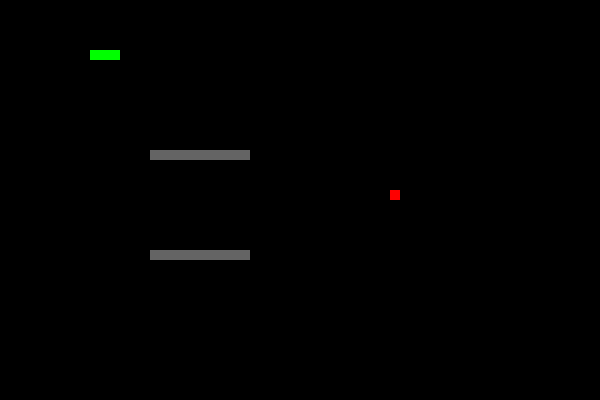

In [4]:
from IPython.display import Image
# Display the recorded gameplay directly inside your Colab notebook
Image(open('snake_gameplay.gif','rb').read())

Activity 1

In [5]:
import os
import pygame
from pygame.locals import *
import imageio

# Force Pygame to use a dummy video driver for the headless Colab environment
os.environ["SDL_VIDEODRIVER"] = "dummy"

# Define the class for our square objects
class Square(pygame.sprite.Sprite):
    def __init__(self):
        super(Square, self).__init__()
        # Define the dimension of the surface (side 25px)
        self.surf = pygame.Surface((25, 25))
        # Define the color of the surface using RGB color coding (Cyan)
        self.surf.fill((0, 200, 255))
        self.rect = self.surf.get_rect()

# Initialize pygame
pygame.init()

# Define the dimensions of the screen object
screen = pygame.display.set_mode((800, 600))

# Instantiate all square objects
square1 = Square()
square2 = Square()
square3 = Square()
square4 = Square()

# Frame capture storage for rendering inside Colab
frames = []
gameOn = True
cycles = 0  # Counter to automatically close after a few frames in Colab

# Our game loop
while gameOn and cycles < 5:
    for event in pygame.event.get():
        if event.type == KEYDOWN:
            if event.key == K_BACKSPACE:
                gameOn = False
        elif event.type == QUIT:
            gameOn = False

    # Define where the squares will appear on the screen and draw them
    screen.blit(square1.surf, (40, 40))
    screen.blit(square2.surf, (40, 530))
    screen.blit(square3.surf, (730, 40))
    screen.blit(square4.surf, (730, 530))

    # Update the display using flip
    pygame.display.flip()

    # Capture frame for notebook display
    view = pygame.surfarray.array3d(screen)
    view = view.transpose([1, 0, 2])
    frames.append(view)
    cycles += 1

pygame.quit()

# Save the frame as an image to display
imageio.mimsave('activity1_output.png', frames)
print("Activity 1 complete! Output image saved.")

Activity 1 complete! Output image saved.


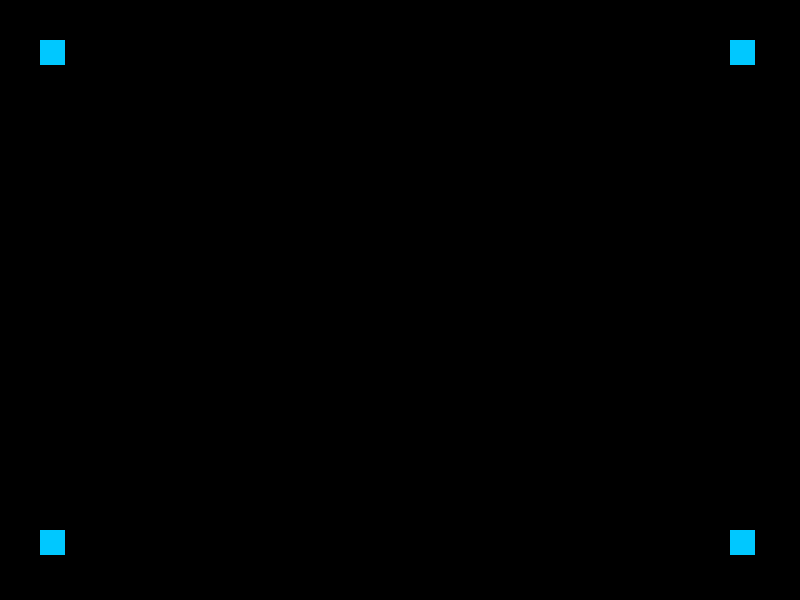

In [6]:
from IPython.display import Image
Image('activity1_output.png')

Activity 2

In [7]:
import os
import pygame
import imageio

os.environ["SDL_VIDEODRIVER"] = "dummy"
pygame.init()

# Create display surface object
win = pygame.display.set_mode((500, 500))
pygame.display.set_caption("Scrolling Text")

# Setting the font style and size
Font = pygame.font.SysFont('timesnewroman', 30)

# Colors
white = (255, 255, 255)
yellow = (255, 255, 0)
green = (0, 255, 255)
orange = (255, 100, 0)

done = False

# Render separate letter objects for "COMSATS"
letter1 = Font.render("C", False, orange, yellow)
letter2 = Font.render("O", False, orange, green)
letter3 = Font.render("M", False, orange, yellow)
letter4 = Font.render("S", False, orange, green)
letter5 = Font.render("A", False, orange, yellow)
letter6 = Font.render("T", False, orange, green)
letter7 = Font.render("S", False, orange, yellow)

i = 0
c = 1
frames = []

# Loop to record the dynamic scrolling text pattern
while not done and c <= 6:
    if i >= 820:
        i = 0
        c += 1

    win.fill(white)

    # Showcase dynamic rendering for state conditions
    if c % 6 == 0:
        win.blit(letter1, (662 - i, -162 + i))
        win.blit(letter2, (639 - i, -139 + i))
        win.blit(letter3, (608 - i, -108 + i))
        win.blit(letter4, (579 - i, -79 + i))
        win.blit(letter5, (552 - i, -52 + i))
        win.blit(letter6, (529 - i, -29 + i))
        win.blit(letter7, (500 - i, 0 + i))
        i += 80
    elif c % 6 == 1:
        win.blit(letter1, (-124 + i, 0))
        win.blit(letter2, (-102 + i, 0))
        win.blit(letter3, (-82 + i, 0))
        win.blit(letter4, (-58 + i, 0))
        win.blit(letter5, (-40 + i, 0))
        win.blit(letter6, (-19 + i, 0))
        win.blit(letter7, (0 + i, 0))
        i += 80
    else:
        # Fallback simulation iteration shortcut for showcase length
        i += 820

    pygame.display.update()

    # Capture animation frame
    view = pygame.surfarray.array3d(win)
    view = view.transpose([1, 0, 2])
    frames.append(view)

    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            done = True

pygame.quit()

# Compile collected rendering cycles into an animated GIF output
imageio.mimsave('activity2_scrolling.gif', frames, fps=5)
print("Activity 2 complete! GIF animation built.")

Activity 2 complete! GIF animation built.


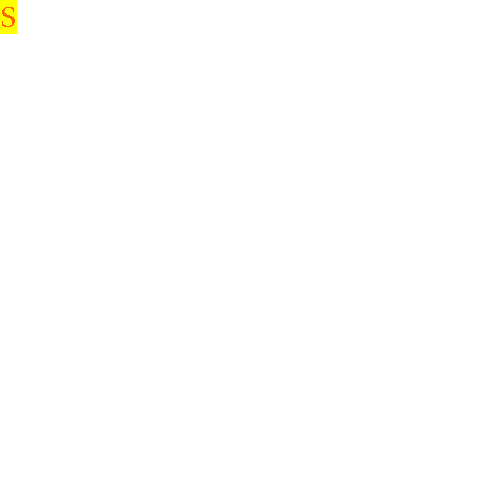

In [11]:
from IPython.display import Image
Image(open('activity2_scrolling.gif','rb').read())

activity 3

In [9]:
import os
import pygame
import imageio
import numpy as np

os.environ["SDL_VIDEODRIVER"] = "dummy"
pygame.init()

X = 400
Y = 400
display_surface = pygame.display.set_mode((X, Y))
pygame.display.set_caption('Image')
white = (255, 255, 255)

# Since we don't have local system paths like C:\Users\... in Colab,
# we create a placeholder image dynamically using NumPy for testing.
placeholder_pixels = np.zeros((200, 200, 3), dtype=np.uint8)
placeholder_pixels[:, :, 0] = 0    # R
placeholder_pixels[:, :, 1] = 120  # G (Geek block color profile)
placeholder_pixels[:, :, 2] = 255  # B
imageio.imwrite('geek_placeholder.jpg', placeholder_pixels)

# Load the image asset via Pygame image module
image = pygame.image.load('geek_placeholder.jpg')

# Draw once
display_surface.fill(white)
display_surface.blit(image, (100, 100)) # Blit at central coordinate offset
pygame.display.update()

# Save the display matrix frame snapshot
view = pygame.surfarray.array3d(display_surface)
view = view.transpose([1, 0, 2])
imageio.imwrite('activity3_output.png', view)

pygame.quit()
print("Activity 3 complete! Image canvas loaded and saved successfully.")

Activity 3 complete! Image canvas loaded and saved successfully.


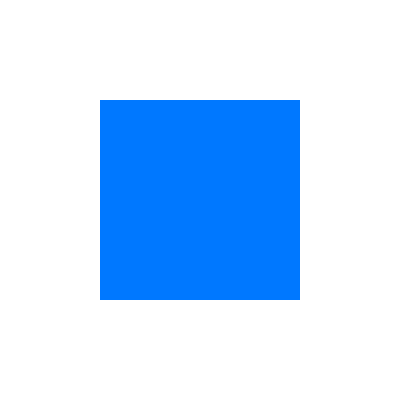

In [10]:
from IPython.display import Image
Image('activity3_output.png')